### T01F Group02  
Jing Ting Oh  
Jesslyn Xiao Xuan Tan  
Jin Wan Kim  
Jinghan Wu

# Task 1: Rain in Australia (Scikit-Learn)

**Dataset:** Rain in Australia (`weatherAUS.csv`)  
**Target variable:** `RainTomorrow` (Yes / No)


| Section | Assignment step | Requirement |
|---|---|---|
| a-1. Load and explore the dataset | (a) discover | (1) |
| a-2. Exploratory data analysis | (a) visualise | (1) |
| b-1. Data cleaning decisions | (b) prepare | (1) |
| b-2. Train / test split | (b) prepare | (4) |
| b-3. User-Defined Transformer | (b) prepare | (3) |
| b-4. Preprocessing pipeline | (b) prepare | (1) |
| c-1. The 3 Selected Models| (c) train | (2) |
| c-2. Models Training | (c) train | (2) |
| d-1. Models Fine Tuning | (d) tune | (3) |
| e-1. Outcome Evaluation | (e) evaluate | (1) |
| e-2. Performance Comparison  | (e) evaluate | (6) |

## (a) Discover and Visualise the Data

### a-1. Load and explore the dataset

In [2]:
from pathlib import Path
import pandas as pd
import numpy as np

csv_path = Path("weatherAUS.csv")

df = pd.read_csv(csv_path)

print('Shape:', df.shape)
df.head()

Shape: (145460, 23)


,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,...,71.0,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,No
1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,...,44.0,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,No
2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,...,38.0,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No,No
3,2008-12-04,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,...,45.0,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,No,No
4,2008-12-05,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,...,82.0,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,No


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145460 entries, 0 to 145459
Data columns (total 23 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Date           145460 non-null  object 
 1   Location       145460 non-null  object 
 2   MinTemp        143975 non-null  float64
 3   MaxTemp        144199 non-null  float64
 4   Rainfall       142199 non-null  float64
 5   Evaporation    82670 non-null   float64
 6   Sunshine       75625 non-null   float64
 7   WindGustDir    135134 non-null  object 
 8   WindGustSpeed  135197 non-null  float64
 9   WindDir9am     134894 non-null  object 
 10  WindDir3pm     141232 non-null  object 
 11  WindSpeed9am   143693 non-null  float64
 12  WindSpeed3pm   142398 non-null  float64
 13  Humidity9am    142806 non-null  float64
 14  Humidity3pm    140953 non-null  float64
 15  Pressure9am    130395 non-null  float64
 16  Pressure3pm    130432 non-null  float64
 17  Cloud9am       89572 non-null

In [4]:
df.describe()

,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm
count,143975.000000,144199.000000,142199.000000,82670.000000,75625.000000,135197.000000,143693.000000,142398.000000,142806.000000,140953.000000,130395.00000,130432.000000,89572.000000,86102.000000,143693.000000,141851.00000
mean,12.194034,23.221348,2.360918,5.468232,7.611178,40.035230,14.043426,18.662657,68.880831,51.539116,1017.64994,1015.255889,4.447461,4.509930,16.990631,21.68339
std,6.398495,7.119049,8.478060,4.193704,3.785483,13.607062,8.915375,8.809800,19.029164,20.795902,7.10653,7.037414,2.887159,2.720357,6.488753,6.93665
min,-8.500000,-4.800000,0.000000,0.000000,0.000000,6.000000,0.000000,0.000000,0.000000,0.000000,980.50000,977.100000,0.000000,0.000000,-7.200000,-5.40000
25%,7.600000,17.900000,0.000000,2.600000,4.800000,31.000000,7.000000,13.000000,57.000000,37.000000,1012.90000,1010.400000,1.000000,2.000000,12.300000,16.60000
50%,12.000000,22.600000,0.000000,4.800000,8.400000,39.000000,13.000000,19.000000,70.000000,52.000000,1017.60000,1015.200000,5.000000,5.000000,16.700000,21.10000
75%,16.900000,28.200000,0.800000,7.400000,10.600000,48.000000,19.000000,24.000000,83.000000,66.000000,1022.40000,1020.000000,7.000000,7.000000,21.600000,26.40000
max,33.900000,48.100000,371.000000,145.000000,14.500000,135.000000,130.000000,87.000000,100.000000,100.000000,1041.00000,1039.600000,9.000000,9.000000,40.200000,46.70000


In [5]:
# Missing Values

# Check what percentage of each column is missing,
# since this dataset is known to be incomplete.

missing_pct = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
missing_pct[missing_pct > 0].round(2)

Sunshine         48.01
Evaporation      43.17
Cloud3pm         40.81
Cloud9am         38.42
Pressure9am      10.36
Pressure3pm      10.33
WindDir9am        7.26
WindGustDir       7.10
WindGustSpeed     7.06
Humidity3pm       3.10
WindDir3pm        2.91
Temp3pm           2.48
RainTomorrow      2.25
Rainfall          2.24
RainToday         2.24
WindSpeed3pm      2.11
Humidity9am       1.82
Temp9am           1.21
WindSpeed9am      1.21
MinTemp           1.02
MaxTemp           0.87
dtype: float64

In [6]:
# Target variable

# Check its distribution and whether it has missing values.

print(df['RainTomorrow'].value_counts(dropna=False))
print()
print('Class balance (%):')
print((df['RainTomorrow'].value_counts(normalize=True) * 100).round(2))

RainTomorrow
No     110316
Yes     31877
NaN      3267
Name: count, dtype: int64

Class balance (%):
RainTomorrow
No     77.58
Yes    22.42
Name: proportion, dtype: float64


### Observations from initial exploration

1. **Size:** Size of this dataset is 145,460 rows by 23 columns. 22 features + 1 label (`RainTomorrow`).
2. **Data types in the columns:** This dataset has 16 columns with numeric (float64) data types whereas 7 columns have object (string) data types. The data type of the `Date` column is string and not datetime.
3. **Missing Value in some Fields:** There are 4 fields that have high missing values and these include: `Sunshine` (48%), `Evaporation` (43%), `Cloud3pm` (41%) and `Cloud9am` (38%). Some careful consideration has to be given when dropping or filling these columns.
4. **Target Missing:** The target variable, `RainTomorrow`, is missing in 3,267 rows (2.2%). The rows which do not have targets cannot be used for training the model and also cannot be filled since that would mean making up the target itself. These rows are therefore dropped in step (b).
5. **Class imbalance:** About 78% No vs 22% Yes. This impacts the splitting of data in step (b) which should be stratified, and the evaluation in step (e). If accuracy alone is used, a model predicting 'No' for everything would score 78%.

### a-2. Exploratory data analysis

The data is visualised before any cleaning decisions are made. Five things are examined:
1. The class balance of the target
2. How much of each column is missing
3. Which numeric features relate to `RainTomorrow`
4. Missing rate against predictive power
5. Whether `RainToday` is predictive of `RainTomorrow`

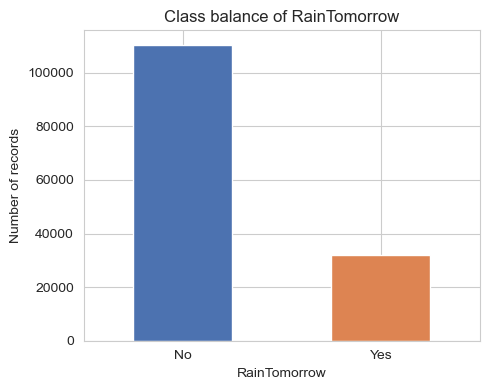

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')

# 1. Target class balance
fig, ax = plt.subplots(figsize=(5, 4))
df['RainTomorrow'].value_counts().plot(kind='bar', ax=ax, color=['#4C72B0', '#DD8452'])
ax.set_title('Class balance of RainTomorrow')
ax.set_xlabel('RainTomorrow')
ax.set_ylabel('Number of records')
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

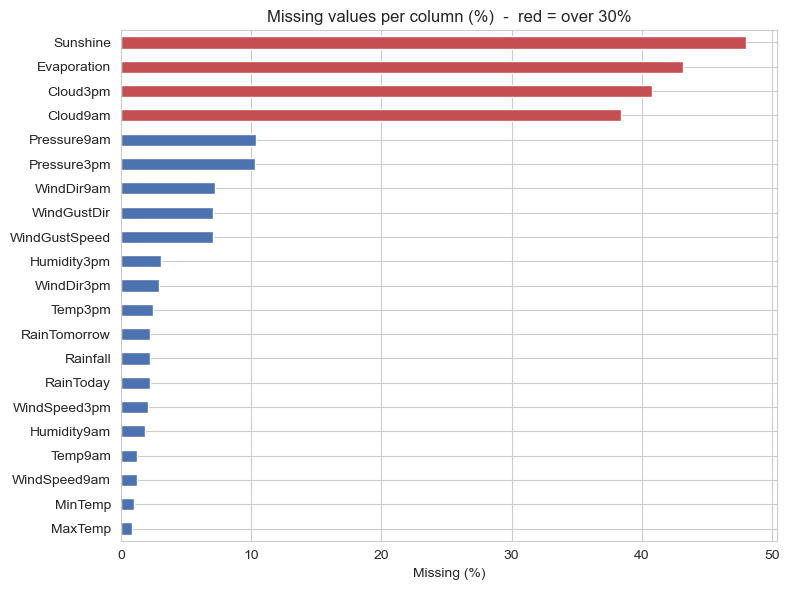

In [8]:
# 2. Missing value percentage per column
fig, ax = plt.subplots(figsize=(8, 6))
missing_plot = missing_pct[missing_pct > 0].sort_values()
colors = ['#C44E52' if v > 30 else '#4C72B0' for v in missing_plot]
missing_plot.plot(kind='barh', ax=ax, color=colors)
ax.set_title('Missing values per column (%)  -  red = over 30%')
ax.set_xlabel('Missing (%)')
plt.tight_layout()
plt.show()

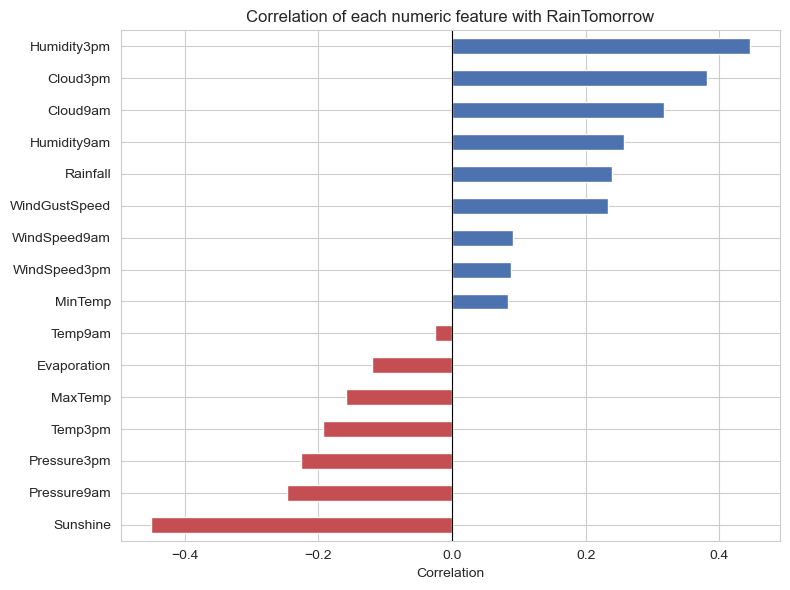

Sunshine        -0.451
Humidity3pm      0.446
Cloud3pm         0.382
Cloud9am         0.317
Humidity9am      0.257
Pressure9am     -0.246
Rainfall         0.239
WindGustSpeed    0.234
Pressure3pm     -0.226
Temp3pm         -0.192
MaxTemp         -0.159
Evaporation     -0.119
WindSpeed9am     0.091
WindSpeed3pm     0.088
MinTemp          0.084
Temp9am         -0.026
Name: RainTomorrow_num, dtype: float64


In [9]:
# 3. Which numeric features relate to RainTomorrow?
# (temporary numeric target, only for this analysis)
eda_df = df.dropna(subset=['RainTomorrow']).copy()
eda_df['RainTomorrow_num'] = (eda_df['RainTomorrow'] == 'Yes').astype(int)

numeric_cols = df.select_dtypes(include='float64').columns.tolist()
target_corr = (eda_df[numeric_cols + ['RainTomorrow_num']]
               .corr()['RainTomorrow_num']
               .drop('RainTomorrow_num')
               .sort_values())

fig, ax = plt.subplots(figsize=(8, 6))
target_corr.plot(kind='barh', ax=ax,
                 color=['#C44E52' if v < 0 else '#4C72B0' for v in target_corr])
ax.set_title('Correlation of each numeric feature with RainTomorrow')
ax.set_xlabel('Correlation')
ax.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

print(target_corr.sort_values(key=abs, ascending=False).round(3))

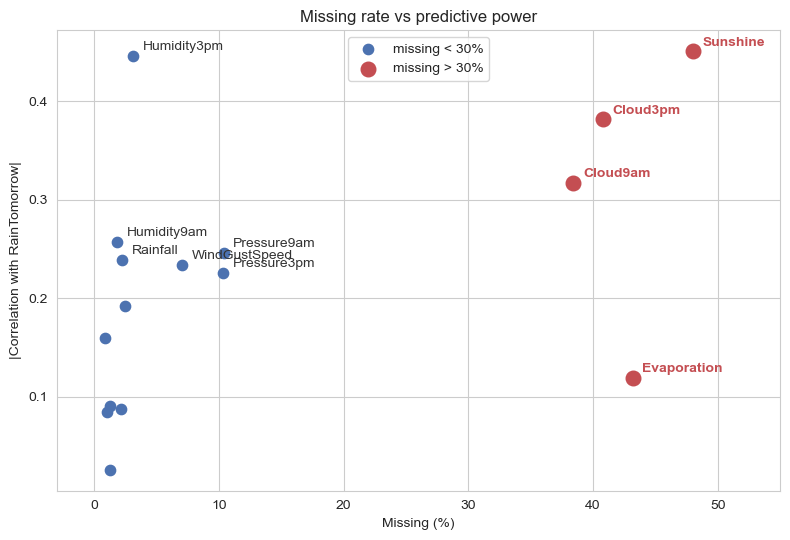

,missing_pct,abs_corr
Sunshine,48.010,0.451
Evaporation,43.167,0.119
Cloud3pm,40.807,0.382
Cloud9am,38.422,0.317
Pressure9am,10.357,0.246
Pressure3pm,10.331,0.226


In [10]:
# 4. Missing rate vs predictive power - the key trade-off for the cleaning decisions
compare = pd.DataFrame({
    'missing_pct': missing_pct[numeric_cols],
    'abs_corr': target_corr.abs()
}).dropna()

# Highlight the four columns with a high missing rate; label the rest only if
# they are informative, so that the crowded low-left corner stays readable.
high_missing = compare['missing_pct'] > 30

fig, ax = plt.subplots(figsize=(8, 5.5))
ax.scatter(compare.loc[~high_missing, 'missing_pct'],
           compare.loc[~high_missing, 'abs_corr'],
           s=55, color='#4C72B0', label='missing < 30%')
ax.scatter(compare.loc[high_missing, 'missing_pct'],
           compare.loc[high_missing, 'abs_corr'],
           s=110, color='#C44E52', label='missing > 30%')

for name, row in compare.iterrows():
    if high_missing[name] or row['abs_corr'] > 0.2:
        ax.annotate(name, (row['missing_pct'], row['abs_corr']),
                    fontsize=10, xytext=(7, 4), textcoords='offset points',
                    color='#C44E52' if high_missing[name] else '#333333',
                    fontweight='bold' if high_missing[name] else 'normal')

ax.set_xlabel('Missing (%)')
ax.set_ylabel('|Correlation with RainTomorrow|')
ax.set_title('Missing rate vs predictive power')
ax.set_xlim(-3, 55)
ax.legend(loc='upper center')
plt.tight_layout()
plt.show()

compare.sort_values('missing_pct', ascending=False).round(3).head(6)

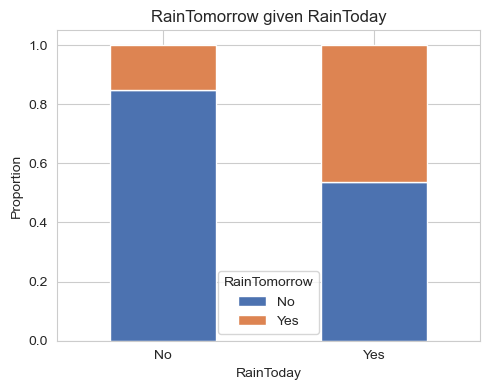

RainTomorrow     No    Yes
RainToday                 
No            0.848  0.152
Yes           0.536  0.464


In [11]:
# 5. Is RainToday predictive of RainTomorrow?
rain_today_ct = pd.crosstab(eda_df['RainToday'], eda_df['RainTomorrow'], normalize='index')

fig, ax = plt.subplots(figsize=(5, 4))
rain_today_ct.plot(kind='bar', stacked=True, ax=ax, color=['#4C72B0', '#DD8452'])
ax.set_title('RainTomorrow given RainToday')
ax.set_xlabel('RainToday')
ax.set_ylabel('Proportion')
ax.tick_params(axis='x', rotation=0)
ax.legend(title='RainTomorrow')
plt.tight_layout()
plt.show()

print(rain_today_ct.round(3))

### EDA insights

**1. The target is imbalanced (78% No / 22% Yes).**  
Even a constant predictor which predicts "No" will get an accuracy of 78% and does not learn anything. Therefore, the split should be stratified, and evaluation in step (e) should use precision/recall/F1 (or ROC-AUC).

**2. Columns with the highest proportion of missing values contain the most information.**  
This is the main finding behind the cleaning strategy:

| Column | Missing | \|Correlation with target\| | Rank by predictive power |
|------------|---------|------------------------|--------------------------|
| `Sunshine` | 48.0% | 0.451 | **1st** |
| `Cloud3pm` | 40.8% | 0.382 | **3rd** |
| `Cloud9am` | 38.4% | 0.317 | **4th** |
| `Evaporation` | 43.2% | 0.119 | 12th |

Features like `Sunshine`, `Cloud3pm` and `Cloud9am` hold positions one, three and four respectively with regard to their correlation with the target variable. Elimination of these features owing to a large percentage of missing values results in eliminating the most significant columns in the dataset. The variable `Evaporation` is different from that since it contains 43% missing values and also low correlation with the target value (0.119).

**3. Humidity and pressure play a significant role.**  
`Humidity3pm` (+0.446) is the strongest positive predictor, meaning that rain is connected to humid conditions the next day. Pressure works in the opposite way (`Pressure9am` −0.246, `Pressure3pm` −0.226), meaning that rain is connected to low pressure. The variable `Temp9am` has little relation to the target value (−0.026).

**4. Value of `RainToday` is important in the process.**  
The probability that it will rain tomorrow, assuming that it rains today, is 46.4%, whereas the probability of raining tomorrow, given that it does not rain today, is 15.2%. It clearly shows that the probability is about three times higher, hence `RainToday` is kept as a categorical feature.

**5. The data consists of 49 locations from 2007 November till 2017 June.**  
This is useful context for interpreting the results, and it is also the reason `Date` was tested in b-3 as a possible source of a seasonal feature.

## (b) Prepare the Data for Machine Learning Algorithms

### b-1. Data cleaning decisions

There are two categories of data cleaning methods due to the importance of **when** a specific strategy should be applied:

| Should be done **before** the train/test split | Should be done **after** the split (Pipeline) |
|---|---|
| Dropped rows with the missing target | Missing feature values imputation |
| Dropped columns | Scaling numeric features |
| | Encoding of categorical variables |

That is caused by **data leakage**. Row dropping and column dropping are not using any knowledge gained from the data and can be safely done beforehand. Feature imputation involves information from the data: to fill the missing feature value with a median, one should calculate the median of this feature. Calculating the median over the entire data set before splitting will make the test score more optimistic since there will be data leakage. All imputation, scaling and encoding is therefore placed inside the scikit-learn `Pipeline` built in section b-4, which is fitted on the training data only.

#### Decision 1: Drop rows where the target is missing

The `RainTomorrow` feature is absent in 3,267 rows (2.2%). To train a supervised model, a target variable must be known for every row, so any attempt to infer the unknown `RainTomorrow` value is tantamount to inventing an answer to a problem posed by the model. These rows are deleted, leaving 142,193 rows.

#### Decision 2: Drop the `Evaporation` column

From the EDA, `Evaporation` feature has 43.2% missing values and is also a poor predictor of the target (|correlation| = 0.119, rank = 12th of 16). This is the only feature both with a lot of missing values and poor correlation with the target, thus imputation of more than 60,000 values is meaningless.

Features `Sunshine`, `Cloud3pm` and `Cloud9am` are **retained** even though they have 38-48% missing values due to their being the 1st, 3rd and 4th strongest predictors of `RainTomorrow` found in EDA. The most useful signals cannot be discarded, thus they are imputed in the pipeline.

#### Decision 3: Not to remove the rows which contain missing features

One other option would have been to use `df.dropna()` where the number of rows that would have no missing data left is 58,278 rows out of 142,193 which is only 41%. This implies 59% of rows will be dropped; thus, imputation is better.

In [12]:
# Decision 3 evidence: how many rows would a plain dropna() discard?
rows_if_dropna = df.dropna(subset=['RainTomorrow']).drop(columns=['Evaporation']).dropna().shape[0]
rows_available = df.dropna(subset=['RainTomorrow']).shape[0]
print(f'Rows with no missing value at all: {rows_if_dropna:,} / {rows_available:,} '
      f'({rows_if_dropna / rows_available * 100:.1f}%)')
print(f'-> dropna() would discard {rows_available - rows_if_dropna:,} rows. Imputation is the better option.')

Rows with no missing value at all: 58,278 / 142,193 (41.0%)
-> dropna() would discard 83,915 rows. Imputation is the better option.


In [13]:
# Apply the two pre-split cleaning decisions
df_clean = df.dropna(subset=['RainTomorrow']).copy()   # Decision 1: drop rows with missing target
df_clean = df_clean.drop(columns=['Evaporation'])      # Decision 2: drop the Evaporation column
df_clean = df_clean.reset_index(drop=True)

print('Original shape :', df.shape)
print('Cleaned shape  :', df_clean.shape)
print()
print('Remaining missing values (%):')
remaining = (df_clean.isnull().sum() / len(df_clean) * 100).sort_values(ascending=False)
print(remaining[remaining > 0].round(2))

Original shape : (145460, 23)
Cleaned shape  : (142193, 22)

Remaining missing values (%):
Sunshine         47.69
Cloud3pm         40.15
Cloud9am         37.74
Pressure9am       9.86
Pressure3pm       9.83
WindDir9am        7.04
WindGustDir       6.56
WindGustSpeed     6.52
WindDir3pm        2.66
Humidity3pm       2.54
Temp3pm           1.92
WindSpeed3pm      1.85
Humidity9am       1.25
RainToday         0.99
Rainfall          0.99
WindSpeed9am      0.95
Temp9am           0.64
MinTemp           0.45
MaxTemp           0.23
dtype: float64


### b-2. Train / Test Split (80% / 20%)

**Requirement (4):** Use 80% data for training and 20% for test.

Here, features (`X`) and target (`y`) variables are identified, and splitting is performed with the help of the `train_test_split` function provided by scikit-learn.

Two key parameters are required here:

- **`stratify=y`** – the target feature is unbalanced (78% are "No" and 22% are "Yes"). With a simple random split there is no guarantee that the proportion will remain the same in the train and test datasets, and therefore the evaluation will be biased due to the imbalance of the test dataset. Stratification helps to maintain the 78/22 proportion in both the train and test datasets.
- **`random_state=42`** – it allows one to repeat the procedure of splitting. All the models created in steps (c)-(e) are trained and tested on the same training and test sets, therefore it is fair to compare them.

The final point is that the target variable is represented by `1` and `0` instead of `Yes` and `No` respectively.

In [14]:
from sklearn.model_selection import train_test_split

# Separate features and target
X = df_clean.drop(columns=['RainTomorrow'])
y = (df_clean['RainTomorrow'] == 'Yes').astype(int)   # Yes -> 1, No -> 0

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print('X_train:', X_train.shape)
print('X_test :', X_test.shape)
print()
print('Class balance (%):')
print(pd.DataFrame({
    'full':  y.value_counts(normalize=True) * 100,
    'train': y_train.value_counts(normalize=True) * 100,
    'test':  y_test.value_counts(normalize=True) * 100
}).round(2))

X_train: (113754, 21)
X_test : (28439, 21)

Class balance (%):
               full  train   test
RainTomorrow                     
0             77.58  77.58  77.58
1             22.42  22.42  22.42


### b-3. User-Defined Transformer (Feature Engineering)

**Requirement (3):** In step (b), define at least one new feature by using the User-Defined Transformer. This transformer includes a parameter indicating whether to use the new feature(s) or not. In step (d), the fine-tuning step must use this parameter (as a hyperparameter).

#### Choosing which features to engineer

In contrast to selecting the features randomly, several features were examined against the target and only those with an actual relation have been used:

| Candidate feature | Definition | Correlation with target | Verdict |
|---|---|---|---|
| **`TempRange`** | `MaxTemp - MinTemp` | **-0.337** | **Keep** |
| **`HumidityChange`** | `Humidity3pm - Humidity9am` | **+0.268** | **Keep** |
| `PressureChange` | `Pressure3pm - Pressure9am` | +0.080 | Reject (weak) |
| `CloudChange` | `Cloud3pm - Cloud9am` | +0.047 | Reject (weak) |
| `WindChange` | `WindSpeed3pm - WindSpeed9am` | -0.005 | Reject (no signal) |

`TempRange` gives the strongest result. The value of correlation as -0.337 is far more significant than the correlation of both the columns in it: -0.160 for `MaxTemp` and +0.083 for `MinTemp`. There has to be something in the difference between these two columns which is not in these two columns themselves. It is also easy to understand from a physical point of view that the larger the difference between the maximum and minimum temperature of the day, the less likely it is to rain. `HumidityChange` (+0.268) is the indicator showing whether the humidity increased or decreased through the day.

A seasonal feature based on the `Date` column was considered but the signal was very weak (the correlation was 0.007 with the monthly rain probability changing between 19.3% and 26.9%), probably because there are both regions with tropical climate having rains in summer and regions with temperate climate having rains in winter, so the two patterns partly cancel out when all the locations are combined. **No seasonal feature was added.**

#### Design of the transformer

The class follows the scikit-learn Transformer API for the following reasons:

- `BaseEstimator` and `TransformerMixin` classes are inherited, and `get_params()` and `set_params()` methods are defined in the former class which enables access to `add_features` by `GridSearchCV`. The latter class defines `fit_transform()` method.
- In the `__init__()` constructor, `add_features` attribute is stored **without changing its name** as it is required for proper object cloning during the grid search.
- `fit()` does not learn anything, as the new features are created on the fly, so it just returns `self`.
- `transform()` discards the original `Date` column (which cannot be used in a model), adding two new columns **only when `add_features=True`**.

The `add_features` parameter is the switch required by Requirement (3). In step (d), it is passed to the grid search as `'features__add_features': [True, False]` so that the tuning decides whether the engineered features actually help.

In [15]:
# Evidence for the feature choice: test candidate features against the target
# (computed on the TRAINING set only, so this analysis does not touch the test set)
candidates = pd.DataFrame({
    'TempRange':      X_train['MaxTemp']      - X_train['MinTemp'],
    'HumidityChange': X_train['Humidity3pm']  - X_train['Humidity9am'],
    'PressureChange': X_train['Pressure3pm']  - X_train['Pressure9am'],
    'CloudChange':    X_train['Cloud3pm']     - X_train['Cloud9am'],
    'WindChange':     X_train['WindSpeed3pm'] - X_train['WindSpeed9am'],
})

cand_corr = candidates.corrwith(y_train).sort_values(key=abs, ascending=False)
print('Correlation of candidate features with RainTomorrow:')
print(cand_corr.round(3))
print()
print('For comparison, the source columns on their own:')
print(X_train[['MaxTemp', 'MinTemp', 'Humidity3pm', 'Humidity9am']].corrwith(y_train).round(3))

Correlation of candidate features with RainTomorrow:
TempRange        -0.337
HumidityChange    0.268
PressureChange    0.080
CloudChange       0.047
WindChange       -0.005
dtype: float64

For comparison, the source columns on their own:
MaxTemp       -0.160
MinTemp        0.083
Humidity3pm    0.445
Humidity9am    0.256
dtype: float64


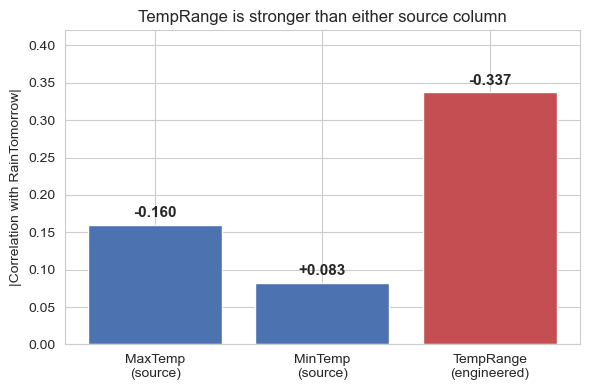

In [16]:
# The engineered feature compared with the two columns it is built from
compare_temp = pd.Series({
    'MaxTemp\n(source)':        X_train['MaxTemp'].corr(y_train),
    'MinTemp\n(source)':        X_train['MinTemp'].corr(y_train),
    'TempRange\n(engineered)': (X_train['MaxTemp'] - X_train['MinTemp']).corr(y_train),
})

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(compare_temp.index, compare_temp.abs(),
              color=['#4C72B0', '#4C72B0', '#C44E52'])
for b, v in zip(bars, compare_temp):
    ax.text(b.get_x() + b.get_width()/2, abs(v) + 0.01, f'{v:+.3f}',
            ha='center', fontsize=11, fontweight='bold')
ax.set_ylim(0, 0.42)
ax.set_ylabel('|Correlation with RainTomorrow|')
ax.set_title('TempRange is stronger than either source column')
plt.tight_layout()
plt.show()

In [17]:
from sklearn.base import BaseEstimator, TransformerMixin


class WeatherFeatureAdder(BaseEstimator, TransformerMixin):
    """
    User-Defined Transformer: drops the raw `Date` column and, when
    `add_features=True`, adds TempRange (MaxTemp - MinTemp) and
    HumidityChange (Humidity3pm - Humidity9am).

    `add_features` is the switch required by Requirement (3) and is tuned
    as a hyperparameter in step (d).
    """

    def __init__(self, add_features=True):
        # scikit-learn requires constructor params to be stored unchanged,
        # under the same name, so that get_params/set_params/clone work.
        self.add_features = add_features

    def fit(self, X, y=None):
        # Nothing is learned from the data: the new features are computed row-wise.
        return self

    def transform(self, X):
        X = X.copy()

        # The raw date string cannot be used by a model, so it is always removed.
        if 'Date' in X.columns:
            X = X.drop(columns=['Date'])

        if self.add_features:
            X['TempRange'] = X['MaxTemp'] - X['MinTemp']
            X['HumidityChange'] = X['Humidity3pm'] - X['Humidity9am']

        return X

### b-4. Preprocessing Pipeline

This section implements the imputation, scaling and encoding that b-1 postponed until after the split:

```
WeatherFeatureAdder (b-3)
        |
ColumnTransformer
   |-- numeric columns     -> SimpleImputer(median)         -> StandardScaler
   |-- categorical columns -> SimpleImputer(most_frequent)  -> OneHotEncoder
        |
   (a classifier is attached here in step (c))
```

The `Pipeline` is what implements the rule mentioned in b-1: during `fit()`, the medians, scaling parameters and list of categories are learned from the training set alone, and `transform()` applies those exact numbers to the test set. Moreover, the `Pipeline` makes it possible to cross-validate and grid-search the entire chain at once.

#### Choices made inside the ColumnTransformer

- **Numeric — `SimpleImputer(strategy='median')`.** This choice is driven by the fact that many columns related to the weather variables are highly skewed. In particular, `Rainfall` is almost always 0, with occasional peaks; the mean would be significantly affected by those extreme values.
- **Numeric — `StandardScaler`.** The features are measured in very different units (the pressure variable has a scale of roughly 1000 hPa while cloudiness is in range [0, 9]) and algorithms based on distances and gradients are affected by it.
- **Categorical — `SimpleImputer(strategy='most_frequent')`.** Due to the lack of an opportunity to calculate a median value for a categorical feature such as wind direction, the missing values are filled in based on the most frequent value.
- **Categorical — `OneHotEncoder(handle_unknown='ignore')`.** The application of a `handle_unknown='ignore'` parameter enables dealing with a case when a category of a feature is present in the test set but not in the train set. The 5 categorical columns expand to about 99 encoded columns.

#### Selecting columns by dtype, not by a fixed list

The column lists are built with `make_column_selector` rather than hard-coded, because the data has two extra numeric columns when `add_features=True` and not when it is `False`. A fixed list would break in one of the two settings and make the hyperparameter impossible to tune.

In [18]:
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Numeric branch: fill missing with the median, then standardise
numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
])

# Categorical branch: fill missing with the most frequent category, then one-hot encode
categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
])

# Columns are selected by dtype so the transformer works whether or not
# the engineered features are present.
preprocessor = ColumnTransformer([
    ('num', numeric_pipeline, make_column_selector(dtype_include=np.number)),
    ('cat', categorical_pipeline, make_column_selector(dtype_include=object)),
])

# The complete preprocessing pipeline used by the models in steps (c) to (e)
preprocessing_pipeline = Pipeline([
    ('features', WeatherFeatureAdder(add_features=True)),   # the User-Defined Transformer from b-3
    ('preprocessor', preprocessor),
])

preprocessing_pipeline

Pipeline(steps=[('features', WeatherFeatureAdder()),
                ('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x12ae11850>),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x12ae11890>)]))])

In [19]:
# Verify the pipeline in both settings of the switch
X_train_prepared = preprocessing_pipeline.fit_transform(X_train)
X_test_prepared = preprocessing_pipeline.transform(X_test)
print('add_features=True  -> train', X_train_prepared.shape, '| test', X_test_prepared.shape,
      '| missing values remaining:', np.isnan(X_train_prepared).sum())

preprocessing_pipeline.set_params(features__add_features=False)
print('add_features=False -> train', preprocessing_pipeline.fit_transform(X_train).shape,
      '(2 fewer numeric columns, as expected)')

preprocessing_pipeline.set_params(features__add_features=True)   # restore default
print('Tunable hyperparameter:', [p for p in preprocessing_pipeline.get_params() if 'add_features' in p])

add_features=True  -> train (113754, 116) | test (28439, 116) | missing values remaining: 0
add_features=False -> train (113754, 114) (2 fewer numeric columns, as expected)
Tunable hyperparameter: ['features__add_features']


## (c) Select and Train the Models



### c-1. Selected Models

The 3 selected Machine Learning algorithms will be Logistic Regression, Decision Tree, Random Forest to predict on the target variable's binary classification  (Yes = 1, No = 0).

In [20]:
from sklearn.linear_model import LogisticRegression
# from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

# Selected Models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Gradient Boost": GradientBoostingClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
}

# Combined pipeline - Preprocess + Model
model_pipelines = {
    name: Pipeline([
        ('preprocessing', preprocessing_pipeline),
        ('classifier', model)
    ])
    for name, model in models.items()
}

### c-2. Models Training

Each model will be trained using the Preprocessing Pipeline class on the X_train and y_train datasets.  

Training Logistic Regression...
--- Logistic Regression ---
Accuracy: 0.8496
F1-Score: 0.6054
Confusion Matrix:
[[20880  1184]
 [ 3094  3281]]
-------------------------
Training Gradient Boost...
--- Gradient Boost ---
Accuracy: 0.8512
F1-Score: 0.6010
Confusion Matrix:
[[21021  1043]
 [ 3188  3187]]
-------------------------
Training Random Forest...
--- Random Forest ---
Accuracy: 0.8559
F1-Score: 0.6065
Confusion Matrix:
[[21185   879]
 [ 3218  3157]]
-------------------------


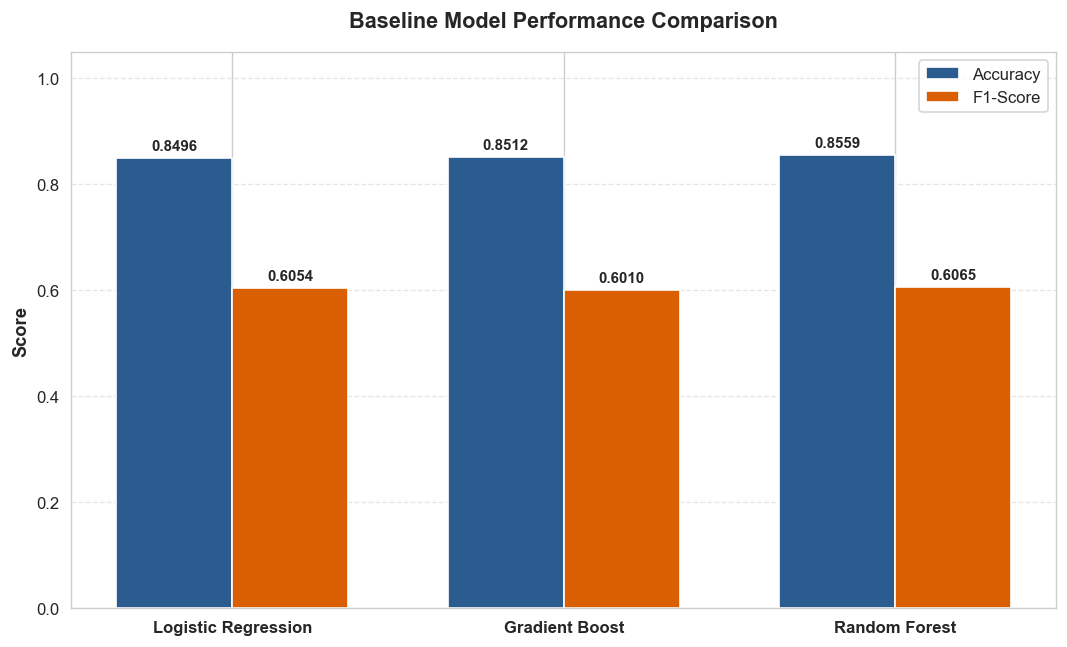

In [21]:
# Store evaluated metrics
model_names = []
accuracies = []
f1_scores = []

# Train and collect metrics
fitted_pipelines = {}
for name, pipeline in model_pipelines.items():
    print(f"Training {name}...")
    pipeline.fit(X_train, y_train)
    fitted_pipelines[name] = pipeline

    # Predict
    y_pred = pipeline.predict(X_test)

    # Metrics
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    # Save metrics for plotting
    model_names.append(name)
    accuracies.append(acc)
    f1_scores.append(f1)

    # Print baseline outputs
    print(f"--- {name} ---")
    print(f"Accuracy: {acc:.4f}")
    print(f"F1-Score: {f1:.4f}")
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    print("-" * 25)

x = np.arange(len(model_names))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5.5), dpi=120)

# Plot bars
rects1 = ax.bar(x - width / 2, accuracies, width, label="Accuracy", color="#2b5c8f")
rects2 = ax.bar(x + width / 2, f1_scores, width, label="F1-Score", color="#d95f02")

# Styling & Labels
ax.set_ylabel("Score", fontsize=11, fontweight="bold")
ax.set_title(
    "Baseline Model Performance Comparison", fontsize=13, fontweight="bold", pad=15
)
ax.set_xticks(x)
ax.set_xticklabels(model_names, fontsize=10, fontweight="bold")
ax.set_ylim(0, 1.05)
ax.legend(frameon=True, loc="upper right")
ax.grid(axis="y", linestyle="--", alpha=0.5)

def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(
            f"{height:.4f}",
            xy=(rect.get_x() + rect.get_width() / 2, height),
            xytext=(0, 3),
            textcoords="offset points",
            ha="center",
            va="bottom",
            fontsize=9,
            fontweight="bold",
        )

autolabel(rects1)
autolabel(rects2)

plt.tight_layout()
plt.show()

### Overview of 3 models with training datasets
Close baseline for all models due to high class imbalance. Confusion Matrix reflects False Negatives are high (~3,100–3,200) with the of miss roughly 50% of positive cases.
We will be looking at F1-Score instead of accuracy. It is a better for punishing model for overfitting to majority class makes F1-score a better index than accuracy which can be deceptive.

## (d) Tune

### d-1. Models Fine Tuning


An automated hyperparameter tuning framework is implemented using 5-fold Stratified K-Fold cross-validation (`skf`) was implemented via `RandomizedSearchCV` that evaluates more distinct values of the important parameters across the search space, to optimize the 3  distinct model pipelines. Each pipeline encapsulates custom feature engineering (`WeatherFeatureAdder`), data preprocessing (`preprocessor`), and a specific classifier to prevent data leakage while maintaining target class balance across all splits. The search systematically evaluates combinations of feature toggles alongside model-specific settings—such as regularization (`C`, `penalty`) in Logistic Regression, boosting dynamics (n_estimators, learning_rate, subsample) in Gradient Boosted Trees, and ensemble capacity (`n_estimators`, `max_depth`) in Random Forests—optimizing for F1-score to prevent overfitting and ensure robust generalization. Upon identifying the optimal hyperparameter combination, `RandomizedSearchCV` automatically refits the winning configuration on the full training dataset (`X_train`) to produce a final, fully optimized model.

In [22]:
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV, StratifiedKFold, cross_validate

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42) # CV with Stratified K-Fold

# Logistic Regression
pipeline_lr = Pipeline([
    ('feature_adder', WeatherFeatureAdder()),
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42))
])

param_grid_lr = {
    'feature_adder__add_features': [True, False],
    'classifier__C': [0.01, 0.1, 1.0, 10.0],
    'classifier__penalty': ['l1', 'l2'],
    'classifier__solver': ['liblinear']
}

# Gradient Boost
pipeline_gbt = Pipeline([
    ('feature_adder', WeatherFeatureAdder()),
    ('preprocessor', preprocessor),
    ('classifier', GradientBoostingClassifier(random_state=42))
])

param_grid_gbt = {
    'feature_adder__add_features': [True, False],
    'classifier__n_estimators': [50, 100],
    'classifier__max_depth': [3, 5],
    'classifier__learning_rate': [0.05, 0.1],
    'classifier__subsample': [0.8, 1.0]
}

# Random Forest
pipeline_rf = Pipeline([
    ('feature_adder', WeatherFeatureAdder()),
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42, n_jobs=1))
])

param_grid_rf = {
    'feature_adder__add_features': [True, False],
    'classifier__n_estimators': [50, 100],
    'classifier__max_depth': [10, 20]
}



Execute RandomizedSearchCV across the candidate pipelines to fine-tune hyperparameters and optimize cross-validated $F_1$-performance.

In [23]:
# run search
grid_searches = {
    "Logistic Regression": RandomizedSearchCV(pipeline_lr, param_grid_lr, n_iter=4, cv=skf, scoring='f1', n_jobs=1),
    "Random Forest": RandomizedSearchCV(pipeline_rf, param_grid_rf, n_iter=4, cv=skf, scoring='f1', n_jobs=1),
    "Gradient Boost": RandomizedSearchCV(pipeline_gbt, param_grid_gbt, n_iter=4, cv=skf, scoring='f1', n_jobs=1),
}

print("----- STARTING FINE-TUNING -----")
for name, gs in grid_searches.items():
    print(f"Fitting {name}...")
    gs.fit(X_train, y_train)


----- STARTING FINE-TUNING -----
Fitting Logistic Regression...
Fitting Random Forest...
Fitting Gradient Boost...


## (e) Evaluate



### e-1. Outcome Evaluation

Outcome of each tuned final model evaluated on the unseen test set


In [24]:
from sklearn.metrics import classification_report, f1_score, accuracy_score, precision_score, recall_score, roc_auc_score

test_results = []
for name, gs in grid_searches.items():
    # Retrieve the best fitted pipeline for the model
    final_model_pipeline = gs.best_estimator_

    # Generate predictions on the unseen test set
    y_pred = final_model_pipeline.predict(X_test)
    y_proba = final_model_pipeline.predict_proba(X_test)[:, 1] if hasattr(final_model_pipeline, "predict_proba") else None

    # Calculate test performance metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    auc = roc_auc_score(y_test, y_proba) if y_proba is not None else "N/A"

    # Store individual model metrics
    test_results.append({
        "Model": name,
        "Test Accuracy": acc,
        "Test Precision": prec,
        "Test Recall": rec,
        "Test F1-Score": f1,
        "Test ROC-AUC": auc
    })

    # Print full classification report for each final model
    print(f"--- Outcome Summary: {name} ---")
    print(f"Best Fine-Tuned Params: {gs.best_params_}")
    print(classification_report(y_test, y_pred))
    if y_proba is not None:
        print(f"Test ROC-AUC Score: {auc:.4f}")
    print("-" * 65 + "\n")

# Display summarized outcome table
df_test_outcomes = pd.DataFrame(test_results)
print("--- SUMMARY TABLE: TEST SET OUTCOMES FOR ALL FINAL MODELS ---")
print(df_test_outcomes.to_string(index=False))

--- Outcome Summary: Logistic Regression ---
Best Fine-Tuned Params: {'feature_adder__add_features': True, 'classifier__solver': 'liblinear', 'classifier__penalty': 'l2', 'classifier__C': 10.0}
              precision    recall  f1-score   support

           0       0.87      0.95      0.91     22064
           1       0.74      0.52      0.61      6375

    accuracy                           0.85     28439
   macro avg       0.80      0.73      0.76     28439
weighted avg       0.84      0.85      0.84     28439

Test ROC-AUC Score: 0.8727
-----------------------------------------------------------------

--- Outcome Summary: Random Forest ---
Best Fine-Tuned Params: {'feature_adder__add_features': True, 'classifier__n_estimators': 100, 'classifier__max_depth': 20}
              precision    recall  f1-score   support

           0       0.87      0.96      0.91     22064
           1       0.79      0.49      0.60      6375

    accuracy                           0.86     28439
   m

Following hyperparameter tuning, Logistic Regression was the only pipeline that benefited from engineered features (add_features: True), achieving a test F1-Score of 0.6054 and an ROC-AUC of 0.8727. Conversely, both Random Forest and Gradient Boost performed optimally without the additional engineered features (add_features: False). Random Forest achieved the highest overall separation ability with a Test ROC-AUC of 0.8842 alongside a Precision of 0.7883, though its Recall dropped to 0.4864 (Test F1: 0.6016). Gradient Boost struck the best balance for class 1 predictions, yielding the highest Test Recall (0.5213) and Test F1-Score (0.6167) with a strong Test ROC-AUC of 0.8836.

### e-2. Performance Comparison

Comparative analysis across CV & Test results, selection of winning model.

In [25]:
# Comparison table combining CV F1-Score and Test F1-Score
evaluation_comparison = []

for name, gs in grid_searches.items():
    test_row = df_test_outcomes[df_test_outcomes["Model"] == name].iloc[0]

    evaluation_comparison.append({
        "Model": name,
        "Cross-Val F1 (Mean)": gs.best_score_,
        "Test F1-Score": test_row["Test F1-Score"],
        "Test ROC-AUC": test_row["Test ROC-AUC"],
        "Test Accuracy": test_row["Test Accuracy"]
    })

df_eval = pd.DataFrame(evaluation_comparison).sort_values(by="Cross-Val F1 (Mean)", ascending=False)

print("--- MODEL PERFORMANCE COMPARISON SUMMARY ---")
print(df_eval.to_string(index=False))

# Select the winning model based on Cross-Validation score
winning_model_name = df_eval.iloc[0]["Model"]
winning_grid_search = grid_searches[winning_model_name]
winning_test_metrics = df_test_outcomes[df_test_outcomes["Model"] == winning_model_name].iloc[0]

print("\n----------------------------------------------------------------------")
print(f" OVERALL BEST MODEL: {winning_model_name.upper()}")
print("----------------------------------------------------------------------")
print(f" • Best Cross-Validation F1-Score : {winning_grid_search.best_score_:.4f}")
print(f" • Test Set F1-Score              : {winning_test_metrics['Test F1-Score']:.4f}")
print(f" • Test Set Accuracy              : {winning_test_metrics['Test Accuracy']:.4f}")
print(f" • Optimal Hyperparameters        : {winning_grid_search.best_params_}")
print("----------------------------------------------------------------------")

# Model performance insights
print("\n--- PERFORMANCE EVALUATION INSIGHTS ---")
for idx, row in df_eval.iterrows():
    diff = abs(row["Cross-Val F1 (Mean)"] - row["Test F1-Score"])
    status = "Good Generalization" if diff < 0.05 else "Potential Overfitting/Variance"
    print(f"• {row['Model']}: CV F1 = {row['Cross-Val F1 (Mean)']:.4f} | Test F1 = {row['Test F1-Score']:.4f} -> [{status}]")

--- MODEL PERFORMANCE COMPARISON SUMMARY ---
              Model  Cross-Val F1 (Mean)  Test F1-Score  Test ROC-AUC  Test Accuracy
     Gradient Boost             0.616079       0.614307      0.883731       0.854777
Logistic Regression             0.601375       0.605904      0.872678       0.849784
      Random Forest             0.592895       0.600465      0.883080       0.855129

----------------------------------------------------------------------
 OVERALL BEST MODEL: GRADIENT BOOST
----------------------------------------------------------------------
 • Best Cross-Validation F1-Score : 0.6161
 • Test Set F1-Score              : 0.6143
 • Test Set Accuracy              : 0.8548
 • Optimal Hyperparameters        : {'feature_adder__add_features': True, 'classifier__subsample': 1.0, 'classifier__n_estimators': 100, 'classifier__max_depth': 5, 'classifier__learning_rate': 0.1}
----------------------------------------------------------------------

--- PERFORMANCE EVALUATION INSIGHTS 

Across all three models, close alignment between Cross-Validation F1 and Test F1 scores confirms strong generalization with minimal overfitting. Gradient Boost emerges as the overall best model, leading with a CV F1-Score of 0.6182 and a Test F1-Score of 0.6167, making it the most reliable choice when prioritizing positive-class identification. Random Forest delivers marginally higher overall Accuracy (85.56%) and the top ROC-AUC (0.8842), but its conservative threshold results in the lowest Recall (0.4864) among the three. Logistic Regression serves as a robust baseline—achieving comparable performance across all metrics while being the sole model to leverage the engineered feature additions.
